In [57]:
import pandas as pd
import re
import time
import nltk
import emoji
import numpy as np
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

In [58]:
# File path
file_path = "Sentiment_Data.csv"

# Load CSV file
df_sample = pd.read_csv(file_path, encoding="ISO-8859-1")

# Sample 8000 reviews if the dataset is larger
if len(df_sample) > 8000:
    df_sample = df_sample.sample(n=8000, random_state=42)

# Check basic stats
print("Sampled Data Shape:", df_sample.shape)
print("\nMissing values:\n", df_sample.isnull().sum())
print("\nDuplicate reviews:", df_sample.duplicated().sum())
print("\nClass distribution:\n", df_sample['Sentiment'].value_counts())


Sampled Data Shape: (8000, 2)

Missing values:
 Tweet        0
Sentiment    0
dtype: int64

Duplicate reviews: 0

Class distribution:
 Sentiment
Strong_Pos    4113
Neutral       1374
Mild_Pos      1137
Strong_Neg     764
Mild_Neg       612
Name: count, dtype: int64


In [ ]:
# # Download necessary NLTK resources
# nltk.download('stopwords')
# nltk.download('punkt')
# nltk.download('wordnet')

# # Initialize lemmatizer
# lemmatizer = WordNetLemmatizer()
# stop_words = set(stopwords.words('english'))

# def preprocess_text(text):
#     # Lowercase text
#     text = text.lower()
    
#     # Remove special characters, numbers, and punctuation
#     text = re.sub(r'[^a-z\s]', '', text)
    
#     # Tokenize words
#     words = word_tokenize(text)
    
#     # Remove stopwords and lemmatize
#     words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
#     return words  # Return list of words

# # Apply preprocessing to the 'Tweet' column
# df_sample['clean_text'] = df_sample['Tweet'].apply(preprocess_text)

# # Display sample processed text
# print(df_sample[['Tweet', 'clean_text']].head())


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/fatemi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/fatemi/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/fatemi/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                                                    Tweet  \
420483  stupid fucking freedom convoy is going past th...   
320604  Freedom Convoy coming to a country near you! S...   
68154   @CTVNews The main thing is that the Freedom/An...   
100473  Residents who Chauvin says previously agreed t...   
303998  MSNBC guest says Freedom Convoy truckers throw...   

                                               clean_text  
420483  [stupid, fucking, freedom, convoy, going, past...  
320604  [freedom, convoy, coming, country, near, start...  
68154   [ctvnews, main, thing, freedomantimandate, con...  
100473  [resident, chauvin, say, previously, agreed, l...  
303998  [msnbc, guest, say, freedom, convoy, trucker, ...  


In [59]:
# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Define slang mapping
slang_dict = {
    "lol": "laughing out loud",
    "brb": "be right back",
    "gtg": "got to go",
    "u": "you",
    "r": "are",
    "idk": "I don't know",
    "omg": "oh my god"
}

# Function to handle emojis and convert them into text
def remove_emoji(text):
    return emoji.demojize(text)

# Preprocess function
def preprocess_text(text):
    # Lowercase text
    text = text.lower()
    
    # Replace slang using slang_dict
    words = text.split()
    words = [slang_dict.get(word, word) for word in words]
    text = " ".join(words)
    
    # Remove special characters, numbers, and punctuation
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Handle emojis and convert them to text
    text = remove_emoji(text)
    
    # Tokenize words
    words = word_tokenize(text)
    
    # Remove stopwords and lemmatize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    return words  # Return list of words

# Apply preprocessing to the 'Tweet' column (or your specific text column)
df_sample['clean_text'] = df_sample['Tweet'].apply(preprocess_text)

# Display sample processed text
print(df_sample[['Tweet', 'clean_text']].head())


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/fatemi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/fatemi/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/fatemi/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                                                    Tweet  \
420483  stupid fucking freedom convoy is going past th...   
320604  Freedom Convoy coming to a country near you! S...   
68154   @CTVNews The main thing is that the Freedom/An...   
100473  Residents who Chauvin says previously agreed t...   
303998  MSNBC guest says Freedom Convoy truckers throw...   

                                               clean_text  
420483  [stupid, fucking, freedom, convoy, going, past...  
320604  [freedom, convoy, coming, country, near, start...  
68154   [ctvnews, main, thing, freedomantimandate, con...  
100473  [resident, chauvin, say, previously, agreed, l...  
303998  [msnbc, guest, say, freedom, convoy, trucker, ...  


In [60]:
# Train Word2Vec model
vector_size = 100  # You can tune this between 64-300
w2v_model = Word2Vec(sentences=df_sample['clean_text'], vector_size=vector_size, 
                      window=5, min_count=2, workers=4, sg=1)  # sg=1 for Skip-gram, sg=0 for CBOW

# Save model for later use
w2v_model.save("word2vec.model")

# Example: Check vector for a word
print(w2v_model.wv['great'])  # Prints vector for "great" if present in vocab


[-0.07442252  0.2661238   0.02685355  0.1804705   0.08124892 -0.25641596
  0.07966063  0.33026466 -0.28659236 -0.08791161 -0.13886508 -0.32863986
 -0.03548726  0.19224645  0.10946682 -0.18601198  0.03900639  0.00501651
 -0.00646876 -0.45966357  0.22361207  0.06389707  0.21869415 -0.03845024
  0.05348466  0.03099258 -0.19329436  0.00508896 -0.2070439  -0.09450728
  0.05754498 -0.04444809  0.1617851  -0.29059178 -0.07272812  0.05216851
  0.22779493 -0.01153032 -0.11111388 -0.26796335  0.01371943 -0.13599467
 -0.2171381   0.04170182  0.09016915 -0.08482838 -0.27234545  0.03991952
  0.12018658  0.29829738  0.14358532 -0.14491458 -0.09656525  0.06318342
  0.1500311   0.06320855  0.119705    0.02608941 -0.18034005  0.33080843
 -0.13844831  0.02276731  0.05557193  0.05331222 -0.13068564  0.17737618
  0.17743403  0.18587512 -0.20854098  0.38467848 -0.03047911  0.1312421
  0.16226181 -0.08509732  0.06513294  0.04179992  0.05147013 -0.01786841
 -0.1030622  -0.02744207 -0.27182055 -0.0767604  -0.

In [61]:
def get_review_vector(words, model, vector_size):
    vectors = [model.wv[word] for word in words if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(vector_size)

# Apply function to each review
df_sample['review_vector'] = df_sample['clean_text'].apply(lambda x: get_review_vector(x, w2v_model, vector_size))

# Convert to numpy array for model training
X = np.vstack(df_sample['review_vector'].values)

print("Shape of feature matrix:", X.shape)  


Shape of feature matrix: (8000, 100)


In [62]:
# Download VADER if not available
nltk.download('vader_lexicon')

# Initialize VADER
sia = SentimentIntensityAnalyzer()

# Feature 1: Review length (number of words)
df_sample['review_length'] = df_sample['clean_text'].apply(len)

# Feature 2: Sentiment score (VADER polarity score)
df_sample['sentiment_score'] = df_sample['clean_text'].apply(lambda x: sia.polarity_scores(" ".join(x))['compound'])

# Normalize features
scaler = StandardScaler()
df_sample[['review_length', 'sentiment_score']] = scaler.fit_transform(df_sample[['review_length', 'sentiment_score']])

# Convert to numpy array
extra_features = df_sample[['review_length', 'sentiment_score']].values

# Combine with Word2Vec features
X_final = np.hstack((X, extra_features))

print("Final feature matrix shape:", X_final.shape)


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/fatemi/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Final feature matrix shape: (8000, 102)


In [63]:
# Map existing sentiment labels to numerical values
sentiment_mapping = {
    'Strong_Pos': 1,
    'Mild_Pos': 1,
    'Neutral': 0,
    'Mild_Neg': -1,
    'Strong_Neg': -1
}

# Apply mapping to the 'Sentiment' column
df_sample['sentiment'] = df_sample['Sentiment'].map(sentiment_mapping)

# Check if mapping worked correctly
print(df_sample[['Sentiment', 'sentiment']].head())

# Now, split the data
X = X_final  # Feature matrix
y = df_sample['sentiment']  # Target labels (sentiment)


         Sentiment  sentiment
420483  Strong_Neg         -1
320604  Strong_Pos          1
68154      Neutral          0
100473    Mild_Pos          1
303998    Mild_Pos          1


In [64]:
# Target variable (sentiment labels)
y = df_sample['sentiment']

# Split into train + validation (90%) and test (10%)
X_train_val, X_test, y_train_val, y_test = train_test_split(X_final, y, test_size=0.1, random_state=42)

# Now split the 90% into train and validation (80% train, 10% validation)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1, random_state=42)

# Check the shapes of the splits
print("Training set shape:", X_train.shape)  
print("Validation set shape:", X_val.shape)  
print("Test set shape:", X_test.shape)


Training set shape: (6480, 102)
Validation set shape: (720, 102)
Test set shape: (800, 102)


Classification Report:
               precision    recall  f1-score   support

          -1       0.70      0.63      0.66       129
           0       0.81      0.39      0.53       119
           1       0.84      0.95      0.89       552

    accuracy                           0.82       800
   macro avg       0.78      0.66      0.70       800
weighted avg       0.81      0.82      0.80       800


Accuracy: 0.8175

Confusion Matrix:
 [[ 81   4  44]
 [ 16  47  56]
 [ 19   7 526]]

Training time: 21.542333841323853

AUC Score: 0.8530


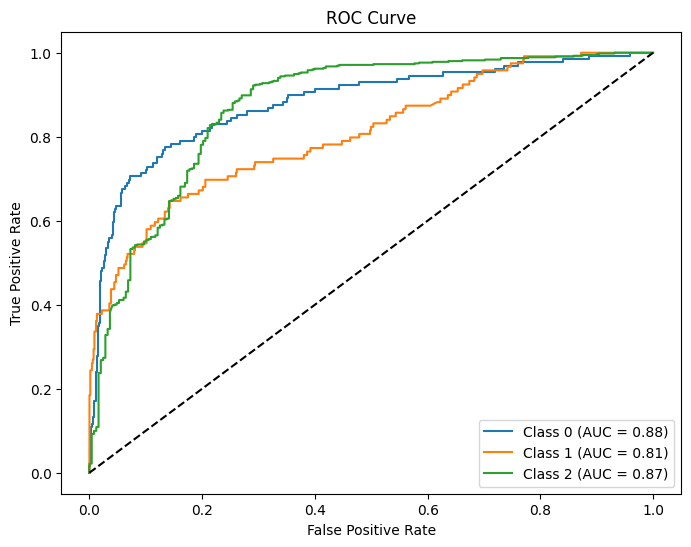

In [65]:
# Track training time
start_time = time.time()

# Train the SVM model
svm = SVC(C=1, kernel='linear', gamma='scale', probability=True)
svm.fit(X_train, y_train)

# Calculate training time
train_time = time.time() - start_time

# Predict and evaluate on the test set
y_pred = svm.predict(X_test)

# Classification report
print("Classification Report:\n", classification_report(y_test, y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Print training time
print("\nTraining time:", train_time)

# Binarize the labels for AUC calculation
y_pred = svm.predict(X_test)
y_prob = svm.predict_proba(X_test)  # Get probability scores for AUC

# AUC Curve
y_test_binarized = label_binarize(y_test, classes=[-1, 0, 1]) 
n_classes = y_test_binarized.shape[1]

auc_score = roc_auc_score(y_test_binarized, y_prob, multi_class='ovr')
print(f"\nAUC Score: {auc_score:.4f}")

plt.figure(figsize=(8, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_prob[:, i])
    auc_score = roc_auc_score(y_test_binarized[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


In [71]:
# Step 1: Initial try with C=4, class_weight={0: 1, 1: 1, -1: 1}
model_1 = SVC(C=1, class_weight={0: 1, 1: 1, -1: 1}, kernel='rbf', gamma='scale')
model_1.fit(X_train, y_train)
y_pred_1 = model_1.predict(X_test)
print("Step 1 Results:")
print(classification_report(y_test, y_pred_1))
print(f"Accuracy: {accuracy_score(y_test, y_pred_1)}\n")

# Step 2: Slightly adjusted C=1, class_weight={0: 1, 1: 1, -1: 1}
model_2 = SVC(C=1, class_weight={0: 1, 1: 1, -1: 1}, kernel='linear', gamma='scale')
model_2.fit(X_train, y_train)
y_pred_2 = model_2.predict(X_test)
print("Step 2 Results:")
print(classification_report(y_test, y_pred_2))
print(f"Accuracy: {accuracy_score(y_test, y_pred_2)}\n")

# Step 3: Further adjusted with C=5, class_weight=={0: 1, 1: 2.5, -1: 1.5}
model_3 = SVC(C=5, class_weight={0: 1, 1: 2.5, -1: 1.5}, kernel='linear', gamma='scale')
model_3.fit(X_train, y_train)
y_pred_3 = model_3.predict(X_test)
print("Step 3 Results:")
print(classification_report(y_test, y_pred_3))
print(f"Accuracy: {accuracy_score(y_test, y_pred_3)}\n")


Step 1 Results:
              precision    recall  f1-score   support

          -1       0.73      0.64      0.68       129
           0       0.84      0.43      0.57       119
           1       0.85      0.96      0.90       552

    accuracy                           0.83       800
   macro avg       0.80      0.68      0.72       800
weighted avg       0.83      0.83      0.82       800

Accuracy: 0.83125

Step 2 Results:
              precision    recall  f1-score   support

          -1       0.70      0.63      0.66       129
           0       0.81      0.39      0.53       119
           1       0.84      0.95      0.89       552

    accuracy                           0.82       800
   macro avg       0.78      0.66      0.70       800
weighted avg       0.81      0.82      0.80       800

Accuracy: 0.8175

Step 3 Results:
              precision    recall  f1-score   support

          -1       0.75      0.60      0.66       129
           0       0.85      0.18      0.30 

In [72]:
# Initialize the SVM model with the chosen hyperparameters
svm_model = SVC(C=1, kernel='rbf', class_weight={0: 1, 1: 1, -1: 1}, gamma='scale', probability=True)

# Cross-validation 
cv_scores = cross_val_score(svm_model, X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1)

# Print the cross-validation results
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean cross-validation score: {cv_scores.mean()}")

# Fit the model on the full training data
svm_model.fit(X_train, y_train)

# Measure test time
start_time = time.time()

# Predict on the test set
y_pred = svm_model.predict(X_test)

# Calculate test time
test_time = time.time() - start_time

# Evaluate on the test set
print("Test time", test_time)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# AUC Score Calculation
y_test_binarized = label_binarize(y_test, classes=[-1, 0, 1])  # Convert to one-vs-rest format
y_pred_prob = svm_model.predict_proba(X_test)  # Get probability scores

auc = roc_auc_score(y_test_binarized, y_pred_prob, multi_class='ovr')
print(f"AUC Score: {auc:.4f}")


Cross-validation scores: [0.81851852 0.81481481 0.81527778]
Mean cross-validation score: 0.8162037037037037
Test time 0.8602428436279297

Classification Report:
               precision    recall  f1-score   support

          -1       0.73      0.64      0.68       129
           0       0.84      0.43      0.57       119
           1       0.85      0.96      0.90       552

    accuracy                           0.83       800
   macro avg       0.80      0.68      0.72       800
weighted avg       0.83      0.83      0.82       800

Accuracy: 0.83125

Confusion Matrix:
 [[ 83   5  41]
 [ 15  51  53]
 [ 16   5 531]]
AUC Score: 0.8113


Top 10 important features and their importance scores:
sentiment_score: 0.2493
review_length: 0.0063
government: 0.0003
vaccine: 0.0003
medium: 0.0003
protester: 0.0003
supporter: 0.0003
let: 0.0003
peaceful: 0.0003
come: 0.0003


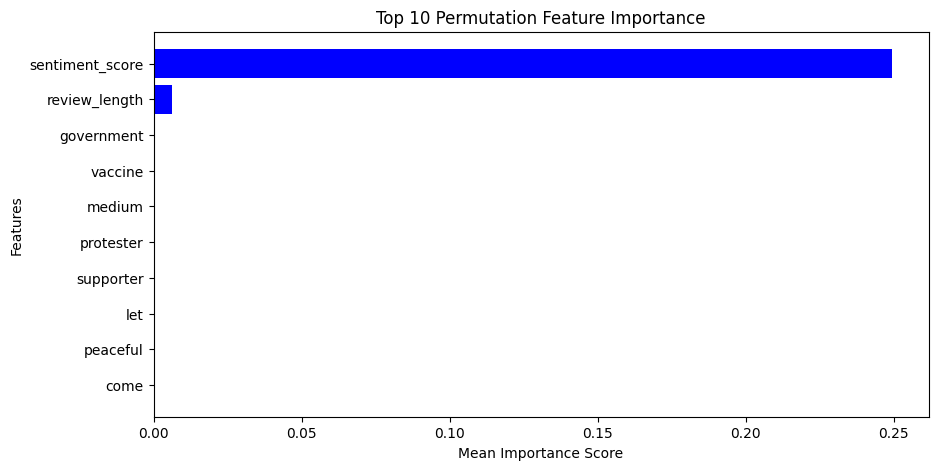

In [77]:
# Load the saved Word2Vec model
w2v_model = Word2Vec.load("word2vec.model")

# Get the vocabulary (list of words) from the Word2Vec model
word2vec_vocab = w2v_model.wv.index_to_key  # Use index_to_key for Gensim 4.x

# Compute Permutation Importance with reduced repeats and subsampling
perm_importance = permutation_importance(
    svm_model, X_test, y_test, scoring="accuracy", 
    random_state=42, n_repeats=5, n_jobs=-1  # Reduced repeats for faster execution
)

# Get feature names (first, the word2vec features, then the other features)
feature_names = [f'word2vec_feat_{i}' for i in range(X_train.shape[1] - 2)] + ['review_length', 'sentiment_score']

# Map word2vec feature indices to actual words for top features only
top_n_features = 10 
top_idx = np.argsort(perm_importance.importances_mean)[::-1][:top_n_features]

# Map the top features to the vocabulary if they are Word2Vec features
mapped_feature_names = []
for i in top_idx:
    if "word2vec_feat" in feature_names[i]:
        word_idx = int(feature_names[i].split('_')[-1])  # Extract index
        if word_idx < len(word2vec_vocab):  # Ensure it's within vocabulary
            mapped_feature_names.append(word2vec_vocab[word_idx])  # Map to word
        else:
            mapped_feature_names.append(feature_names[i])  # Use original feature name
    else:
        mapped_feature_names.append(feature_names[i])  # Keep original features

# Get importance scores for the top N features
top_importance_scores = perm_importance.importances_mean[top_idx]

# Print out the top features with their importance scores
print("Top 10 important features and their importance scores:")
for feature, score in zip(mapped_feature_names, top_importance_scores):
    print(f"{feature}: {score:.4f}")

# Plot the top 10 feature importance
plt.figure(figsize=(10, 5))
plt.barh(mapped_feature_names, top_importance_scores, color='blue')
plt.xlabel("Mean Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Permutation Feature Importance")
plt.gca().invert_yaxis()  # Invert y-axis to show most important at the top
plt.show()
